In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [4]:
DATA_DIR = Path("../data/casting_512x512")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [5]:
BATCH_SIZE = 32
SEED = 42

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=["ok_front", "def_front"],
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.


In [7]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    class_names=["ok_front", "def_front"],
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [8]:
print("Class names:", train_dataset.class_names)

Class names: ['ok_front', 'def_front']


In [9]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels.numpy()[:10])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)
First 10 labels: [[0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]]


In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

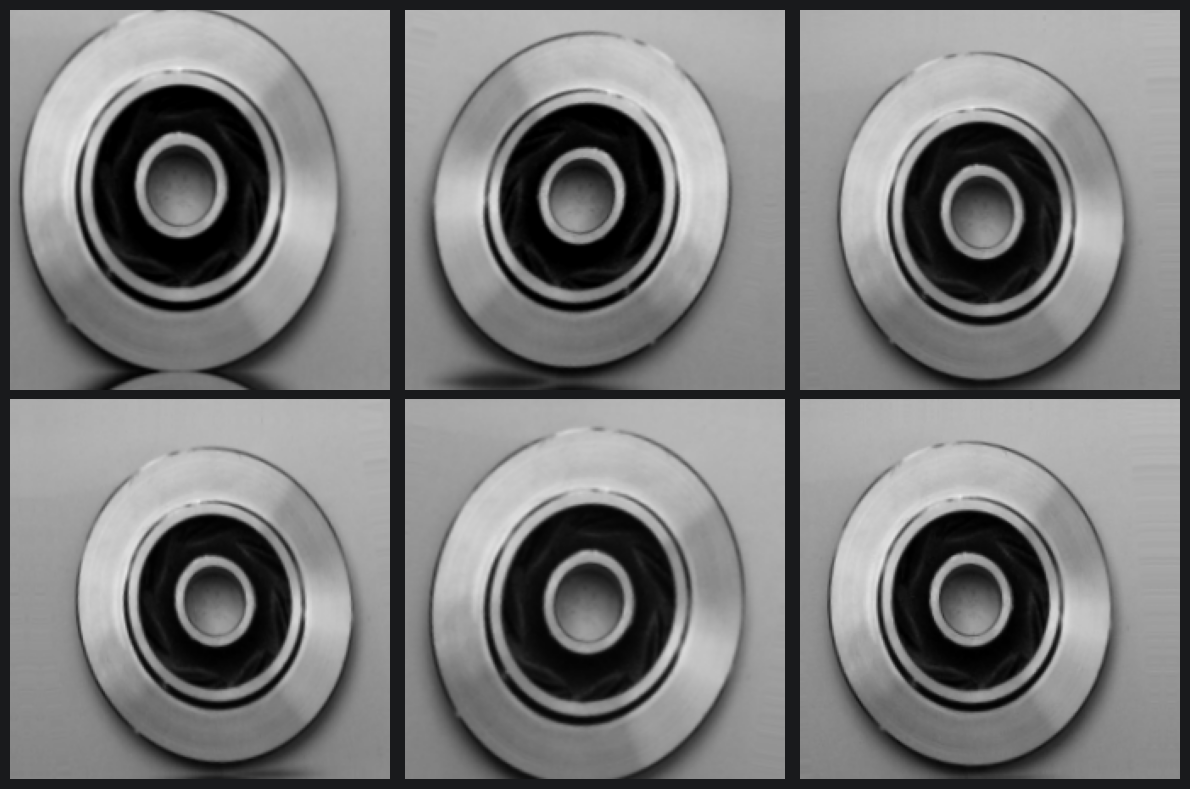

In [11]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    sample_image = images[0]

    for i in range(6):
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )
        plt.axis("off")

plt.tight_layout()
plt.show()